In [3]:
import numpy as np
import warnings
import torch
import torch.nn as nn
import pandas as pd
import os
import importlib
import sys
from tqdm import tqdm
from torchvision import transforms
import torchvision.models as models 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import optuna

batch_size = 256

import torchsummary


torch.manual_seed(42)

In [6]:
# 1. Konfiguration
REPO_URL = "https://github.com/828w5tjjts-wq/Machine-Learning-Final-project.git"
PROJECT_DIR = "/kaggle/working/Machine-Learning-Final-project"

# 2. Prüfen, ob das Repo schon existiert
if os.path.exists(PROJECT_DIR):
    print("Repo existiert bereits. Ziehe neueste Änderungen (Pull)...")
    %cd {PROJECT_DIR}
    !git pull origin main
else:
    print("Repo existiert nicht. Klone von GitHub...")
    !git clone {REPO_URL} {PROJECT_DIR}
    %cd {PROJECT_DIR}

# 3. Pfad zum System-Pfad hinzufügen (damit Imports funktionieren)
sys.path.append(PROJECT_DIR)

print("Setup abgeschlossen. Projekt ist aktuell.")

Repo existiert bereits. Ziehe neueste Änderungen (Pull)...
/kaggle/working/Machine-Learning-Final-project
From https://github.com/828w5tjjts-wq/Machine-Learning-Final-project
 * branch            main       -> FETCH_HEAD
Already up to date.
Setup abgeschlossen. Projekt ist aktuell.


In [7]:
from src.models.architectures import MLPModel
from src.models.architectures import WideMLPModel
from src.models.architectures import MLPModel_V2
from src.models.architectures import MLPModel_V3
from src.models.architectures import DeepResidualMLP
from src.models.trainer import run_training
from src.data.loader import prepare_data
from src.data.loader import load_processed_data
from src.data.edit import split_data
from src.data.edit import standardize_data
from src.data.dataset import create_dataloaders
from src.models.tune import test_learning_rates
from src.models.tune import test_learning_rates_curves
from src.models.trainer import train_model_with_early_stopping
from src.data.cleaner import clean_target
from src.data.dataset import create_dataloaders

In [8]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


In [9]:
X_raw, y = load_processed_data('/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/X_filtered.npy'
,'/kaggle/input/datasets/nilsmatthiessen/processed-data/Machine-Learning-Final-project/y.npy' )

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)
X_train_scaled, X_val_scaled, X_test_scaled = standardize_data(X_train, X_val, X_test)
    
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, X_val_scaled, X_test_scaled, 
    y_train, y_val, y_test, 
    batch_size=batch_size
    )
print("\nAlles bereit für das Training!")

sample_inputs, _ = next(iter(train_loader))
input_dim = sample_inputs.shape[1]

model_linear = MLPModel(input_dim, 1)
model_linear = model_linear.to(device)

loss_function = torch.nn.MSELoss() # Mean Squared Error für Regression
optimizer = torch.optim.Adam(model_linear.parameters(), lr=0.1) 
num_epochs = 100


Daten geladen: X Shape (9229, 78), y Shape (9229,)
Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6

Alles bereit für das Training!


In [6]:
model_mlp = MLPModel(input_dim=input_dim, output_dim=1).to(device)

# 2. Loss Function und Optimizer
loss_function = nn.MSELoss()
# Wir probieren 0.01, da MLPs empfindlicher auf große Sprünge reagieren können als lineare Modelle
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.1) 


In [7]:
train_losses, val_losses, train_rmses, val_rmses = run_training(
    model=model_mlp,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=50,
    train_dataloader=train_loader,
    val_dataloader=val_loader
)

Starte Training für 50 Epochen...


<div><p>Epoch 1/50 | Train Loss (MSE): 7951.7835 | Train RMSE:       89.82€ | Val Loss (MSE):   5339.9312 | Val RMSE:         74.10€</p><p>Epoch 2/50 | Train Loss (MSE): 4260.8292 | Train RMSE:       65.47€ | Val Loss (MSE):   5529.4642 | Val RMSE:         75.18€</p><p>Epoch 3/50 | Train Loss (MSE): 5508.1816 | Train RMSE:       74.79€ | Val Loss (MSE):   4361.9554 | Val RMSE:         66.59€</p><p>Epoch 4/50 | Train Loss (MSE): 3752.0260 | Train RMSE:       61.26€ | Val Loss (MSE):   4261.4983 | Val RMSE:         66.69€</p><p>Epoch 5/50 | Train Loss (MSE): 5601.7568 | Train RMSE:       70.09€ | Val Loss (MSE):   4213.5606 | Val RMSE:         64.80€</p><p>Epoch 6/50 | Train Loss (MSE): 5853.7276 | Train RMSE:       75.70€ | Val Loss (MSE):   4155.2952 | Val RMSE:         65.04€</p><p>Epoch 7/50 | Train Loss (MSE): 4157.0963 | Train RMSE:       64.79€ | Val Loss (MSE):   3305.5896 | Val RMSE:         57.07€</p><p>Epoch 8/50 | Train Loss (MSE): 5524.9740 | Train RMSE:       73.81€ | Val Loss (MSE):   4176.5451 | Val RMSE:         65.11€</p><p>Epoch 9/50 | Train Loss (MSE): 3814.3898 | Train RMSE:       62.31€ | Val Loss (MSE):   2607.6338 | Val RMSE:         50.75€</p><p>Epoch 10/50 | Train Loss (MSE): 4298.8984 | Train RMSE:       64.53€ | Val Loss (MSE):   3214.0276 | Val RMSE:         57.37€</p><p>Epoch 11/50 | Train Loss (MSE): 3439.5915 | Train RMSE:       59.05€ | Val Loss (MSE):   2939.7101 | Val RMSE:         54.22€</p><p>Epoch 12/50 | Train Loss (MSE): 3651.3798 | Train RMSE:       60.42€ | Val Loss (MSE):   3788.4199 | Val RMSE:         62.83€</p><p>Epoch 13/50 | Train Loss (MSE): 4531.2591 | Train RMSE:       67.65€ | Val Loss (MSE):   2292.2243 | Val RMSE:         47.61€</p><p>Epoch 14/50 | Train Loss (MSE): 2902.0160 | Train RMSE:       54.23€ | Val Loss (MSE):   1923.6772 | Val RMSE:         44.78€</p><p>Epoch 15/50 | Train Loss (MSE): 2898.0063 | Train RMSE:       53.81€ | Val Loss (MSE):   1876.6080 | Val RMSE:         44.33€</p><p>Epoch 16/50 | Train Loss (MSE): 3677.7246 | Train RMSE:       60.60€ | Val Loss (MSE):   5593.7831 | Val RMSE:         75.75€</p><p>Epoch 17/50 | Train Loss (MSE): 4501.2993 | Train RMSE:       67.24€ | Val Loss (MSE):   2706.4229 | Val RMSE:         52.62€</p><p>Epoch 18/50 | Train Loss (MSE): 2598.0206 | Train RMSE:       51.37€ | Val Loss (MSE):   1710.5705 | Val RMSE:         42.11€</p><p>Epoch 19/50 | Train Loss (MSE): 2113.5536 | Train RMSE:       46.26€ | Val Loss (MSE):   1436.8833 | Val RMSE:         38.82€</p><p>Epoch 20/50 | Train Loss (MSE): 2905.9788 | Train RMSE:       54.23€ | Val Loss (MSE):   2116.3160 | Val RMSE:         47.19€</p><p>Epoch 21/50 | Train Loss (MSE): 2676.9146 | Train RMSE:       52.09€ | Val Loss (MSE):   1691.7240 | Val RMSE:         42.34€</p><p>Epoch 22/50 | Train Loss (MSE): 2247.4283 | Train RMSE:       47.45€ | Val Loss (MSE):   1676.1299 | Val RMSE:         41.22€</p><p>Epoch 23/50 | Train Loss (MSE): 2891.2831 | Train RMSE:       54.16€ | Val Loss (MSE):   1859.9396 | Val RMSE:         44.08€</p><p>Epoch 24/50 | Train Loss (MSE): 2469.7855 | Train RMSE:       50.04€ | Val Loss (MSE):   1893.1065 | Val RMSE:         43.98€</p><p>Epoch 25/50 | Train Loss (MSE): 4370.5599 | Train RMSE:       62.66€ | Val Loss (MSE):   23118.7314 | Val RMSE:         153.84€</p><p>Epoch 26/50 | Train Loss (MSE): 9765.6436 | Train RMSE:       98.65€ | Val Loss (MSE):   5543.8207 | Val RMSE:         75.43€</p><p>Epoch 27/50 | Train Loss (MSE): 4911.6057 | Train RMSE:       69.78€ | Val Loss (MSE):   2058.0397 | Val RMSE:         46.35€</p><p>Epoch 28/50 | Train Loss (MSE): 3569.3010 | Train RMSE:       60.21€ | Val Loss (MSE):   2025.9983 | Val RMSE:         46.30€</p><p>Epoch 29/50 | Train Loss (MSE): 4475.8961 | Train RMSE:       66.78€ | Val Loss (MSE):   2104.8917 | Val RMSE:         46.51€</p><p>Epoch 30/50 | Train Loss (MSE): 3157.4987 | Train RMSE:       56.45€ | Val Loss (MSE):   1771.4445 | Val RMSE:         42.80€</p><p>Epoch 31/50 | Train Loss (MSE): 3274.05

Training beendet.


In [8]:
# 1. Den Index des minimalen Validation RMSE finden
best_epoch_idx = np.argmin(val_rmses)

# 2. Die Werte an diesem Index auslesen
best_epoch = best_epoch_idx + 1 # Epochen fangen bei 1 an für Menschen
best_val_rmse = val_rmses[best_epoch_idx]
best_train_rmse = train_rmses[best_epoch_idx]
best_val_loss = val_losses[best_epoch_idx]

print("="*50)
print(f"BESTER DURCHLAUF (Epoche {best_epoch}):")
print("-" * 50)
print(f"Train RMSE: {best_train_rmse:.2f}€")
print(f"Val RMSE:   {best_val_rmse:.2f}€  <-- BESTES ERGEBNIS")
print(f"Val Loss:   {best_val_loss:.4f}")
print("="*50)

BESTER DURCHLAUF (Epoche 45):
--------------------------------------------------
Train RMSE: 51.58€
Val RMSE:   37.85€  <-- BESTES ERGEBNIS
Val Loss:   1358.8223


In [9]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
resnet = models.resnet18(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1]) 
resnet.to(device)
resnet.eval() # Evaluation mode (kein Training nötig)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [38]:
def extract_features_from_urls(url_list):
    features_list = []
    for url in tqdm(url_list, desc="Extrahiere Bild-Features"):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                features = resnet(img_tensor)
            
            features_list.append(features.flatten().cpu().numpy())
        except:
            # Falls Fehler: Null-Vektor
            features_list.append(np.zeros(512))
            
    return np.array(features_list)


In [39]:
print("Lade listings.csv...")
df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
df = clean_target(df)

Lade listings.csv...


In [40]:
image_path = 'X_images.npy'
#evtl freeze requires grad = false

if os.path.exists(image_path):
    print(f"\nLade existierende Bild-Features von '{image_path}'...")
    X_images = np.load(image_path, allow_pickle=True)
    
else:
    print("Datei nicht gefunden. Lade Bilder...")
    df = pd.read_csv("/kaggle/input/datasets/nilsmatthiessen/listings/listings-2.csv")
    df = clean_target(df)
    urls = df['picture_url'].tolist()
    print("Starte Bild-Download und Feature Extraktion...")
    X_images = extract_features_from_urls(urls)
    np.save(image_path, X_images)
    print(f"Bild-Features gespeichert! Shape: {X_images.shape}")

Datei nicht gefunden. Lade Bilder...
Starte Bild-Download und Feature Extraktion...


Extrahiere Bild-Features: 100%|██████████| 9229/9229 [00:00<00:00, 340984.40it/s]

Bild-Features gespeichert! Shape: (9229, 512)


In [41]:
y = df['price'].values
X_train_img, X_val_img, X_test_img, y_train, y_val, y_test = split_data(X_images, y)
X_train_img_scaled, X_val_img_scaled, X_test_img_scaled = standardize_data(X_train_img,X_val_img,X_test_img)
train_loader_img, val_loader_img, test_loader_img = create_dataloaders(
    X_train=X_train_img_scaled,
    X_val=X_val_img_scaled,
    X_test=X_test_img_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=batch_size
)


Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6


In [42]:
img_model_MLP_V1 = MLPModel(input_dim=512, output_dim=1).to(device)
optimizer_V1 = torch.optim.Adam(img_model_MLP_V1.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()

img_model_MLP_V2 = MLPModel_V2(input_dim=512, output_dim=1).to(device)
optimizer_V2 = torch.optim.Adam(img_model_MLP_V2.parameters(), lr=0.1)

img_model_MLP_V3 = MLPModel_V3(input_dim=512, output_dim=1).to(device)
optimizer_V3 = torch.optim.Adam(img_model_MLP_V3.parameters(), lr=0.1)


In [43]:
train_losses_V1, val_losses_V1, train_rmses_V1, val_rmses_V1 = run_training(
    model=img_model_MLP_V1,
    optimizer=optimizer_V1,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V2, val_losses_V2, train_rmses_V2, val_rmses_V2 = run_training(
    model=img_model_MLP_V2,
    optimizer=optimizer_V2,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)
train_losses_V3, val_losses_V3, train_rmses_V3, val_rmses_V3 = run_training(
    model=img_model_MLP_V3,
    optimizer=optimizer_V3,
    loss_function=loss_function,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)



# Besten Durchlauf finden
best_epoch_idx = np.argmin(val_rmses)
print(f"\nBester Durchlauf war Epoche {best_epoch_idx+1} mit Val RMSE: {val_rmses[best_epoch_idx]:.2f}€")

Starte Training für 50 Epochen...


<div><div><progress max="50" value="31"></progress> 62.00% [31/50 00:05&lt;00:03]</div><div><p>Epoch 1/50 | Train Loss (MSE): 16181.2000 | Train RMSE:       128.16€ | Val Loss (MSE):   10933.5697 | Val RMSE:         102.50€</p><p>Epoch 2/50 | Train Loss (MSE): 11665.5708 | Train RMSE:       108.36€ | Val Loss (MSE):   11045.7386 | Val RMSE:         102.68€</p><p>Epoch 3/50 | Train Loss (MSE): 11618.7100 | Train RMSE:       107.91€ | Val Loss (MSE):   10881.6718 | Val RMSE:         101.92€</p><p>Epoch 4/50 | Train Loss (MSE): 11654.6988 | Train RMSE:       108.07€ | Val Loss (MSE):   10826.2721 | Val RMSE:         101.67€</p><p>Epoch 5/50 | Train Loss (MSE): 11465.8181 | Train RMSE:       107.22€ | Val Loss (MSE):   10883.6862 | Val RMSE:         101.93€</p><p>Epoch 6/50 | Train Loss (MSE): 11618.1144 | Train RMSE:       106.76€ | Val Loss (MSE):   10684.2950 | Val RMSE:         101.03€</p><p>Epoch 7/50 | Train Loss (MSE): 11374.3441 | Train RMSE:       107.54€ | Val Loss (MSE):   10783.7310 | Val RMSE:         101.47€</p><p>Epoch 8/50 | Train Loss (MSE): 11305.6365 | Train RMSE:       107.10€ | Val Loss (MSE):   11003.1576 | Val RMSE:         102.49€</p><p>Epoch 9/50 | Train Loss (MSE): 11261.8061 | Train RMSE:       107.06€ | Val Loss (MSE):   10638.4613 | Val RMSE:         100.83€</p><p>Epoch 10/50 | Train Loss (MSE): 11305.6194 | Train RMSE:       107.19€ | Val Loss (MSE):   10753.3907 | Val RMSE:         101.34€</p><p>Epoch 11/50 | Train Loss (MSE): 11319.2924 | Train RMSE:       106.82€ | Val Loss (MSE):   10615.3500 | Val RMSE:         100.76€</p><p>Epoch 12/50 | Train Loss (MSE): 11496.2024 | Train RMSE:       106.90€ | Val Loss (MSE):   10706.5847 | Val RMSE:         101.13€</p><p>Epoch 13/50 | Train Loss (MSE): 11476.0381 | Train RMSE:       106.52€ | Val Loss (MSE):   10691.0649 | Val RMSE:         101.06€</p><p>Epoch 14/50 | Train Loss (MSE): 11177.0432 | Train RMSE:       106.56€ | Val Loss (MSE):   10616.2799 | Val RMSE:         100.76€</p><p>Epoch 15/50 | Train Loss (MSE): 11617.8717 | Train RMSE:       106.40€ | Val Loss (MSE):   10631.5138 | Val RMSE:         100.88€</p><p>Epoch 16/50 | Train Loss (MSE): 11644.0716 | Train RMSE:       106.77€ | Val Loss (MSE):   10646.2271 | Val RMSE:         100.86€</p><p>Epoch 17/50 | Train Loss (MSE): 12061.7300 | Train RMSE:       106.43€ | Val Loss (MSE):   10630.2917 | Val RMSE:         100.80€</p><p>Epoch 18/50 | Train Loss (MSE): 11521.7154 | Train RMSE:       106.57€ | Val Loss (MSE):   10881.1698 | Val RMSE:         101.92€</p><p>Epoch 19/50 | Train Loss (MSE): 11181.2938 | Train RMSE:       106.26€ | Val Loss (MSE):   10684.8744 | Val RMSE:         101.03€</p><p>Epoch 20/50 | Train Loss (MSE): 11266.5326 | Train RMSE:       106.40€ | Val Loss (MSE):   10616.0744 | Val RMSE:         100.76€</p><p>Epoch 21/50 | Train Loss (MSE): 11280.5592 | Train RMSE:       106.70€ | Val Loss (MSE):   10615.5288 | Val RMSE:         100.77€</p><p>Epoch 22/50 | Train Loss (MSE): 12701.9602 | Train RMSE:       106.11€ | Val Loss (MSE):   10687.2961 | Val RMSE:         101.04€</p><p>Epoch 23/50 | Train Loss (MSE): 11155.4313 | Train RMSE:       106.40€ | Val Loss (MSE):   10625.8610 | Val RMSE:         100.79€</p><p>Epoch 24/50 | Train Loss (MSE): 11217.8015 | Train RMSE:       106.05€ | Val Loss (MSE):   10643.7106 | Val RMSE:         100.85€</p><p>Epoch 25/50 | Train Loss (MSE): 11239.5291 | Train RMSE:       106.79€ | Val Loss (MSE):   10660.9032 | Val RMSE:         100.93€</p><p>Epoch 26/50 | Train Loss (MSE): 12049.4692 | Train RMSE:       106.31€ | Val Loss (MSE):   10794.2214 | Val RMSE:         101.52€</p><p>Epoch 27/50 | Train Loss (MSE): 11182.3669 | Train RMSE:       106.37€ | Val Loss (MSE):   10647.8665 | Val RMSE:         100.87€</p><p>Epoch 28/50 | Train Loss (MSE): 11549.6230 | Train RMSE:       106.36€ | Val Loss (MSE):   10627.3891 | Val RMSE:         100.86€</p><p>Epoch 29/50 | Train Loss (MSE): 11150.3705 | Train RMSE:       106.32€ | Val Loss (MSE):   10642.9374 | Va

KeyboardInterrupt: 

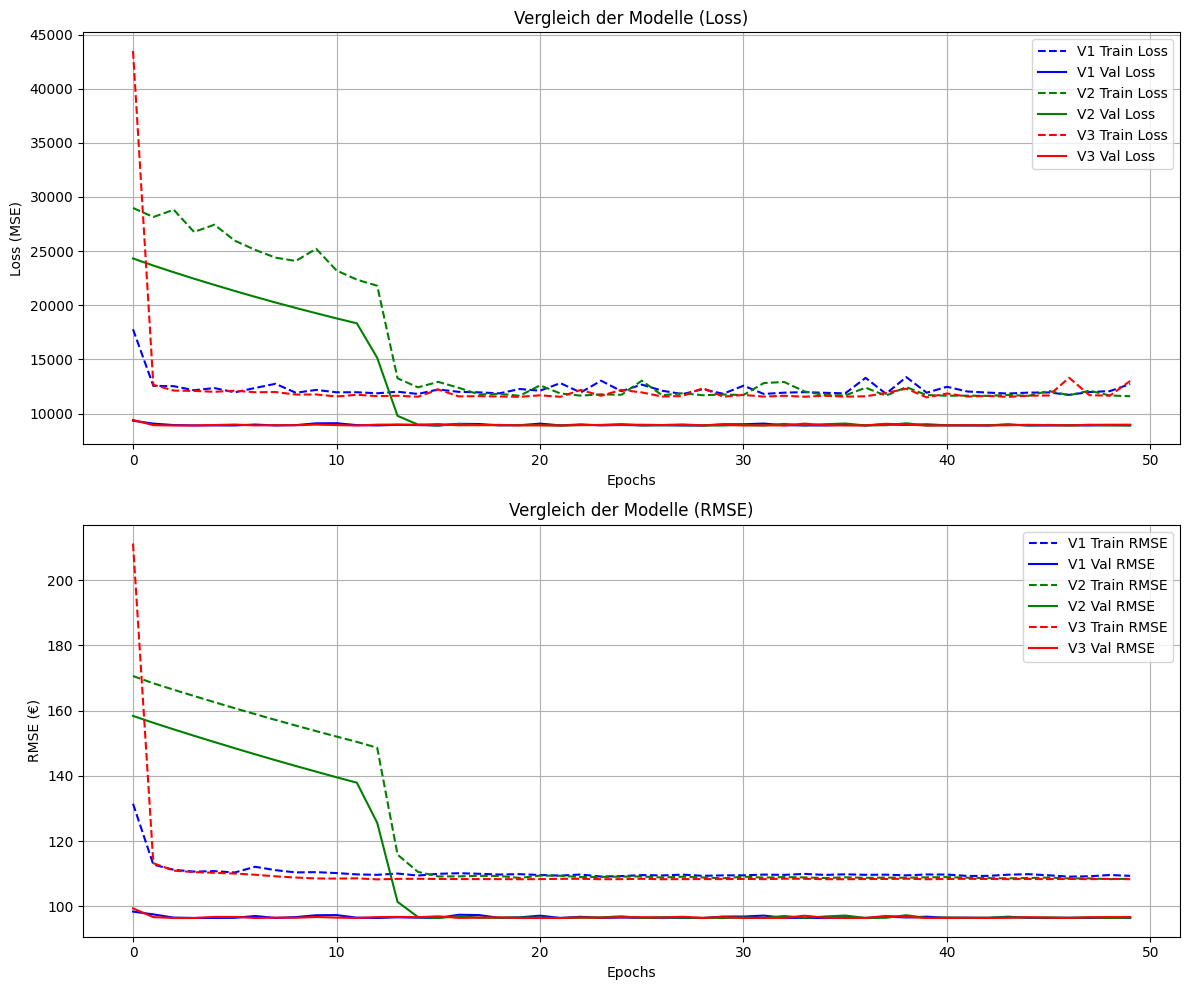


--- Beste Ergebnisse (Validation RMSE) ---
Modell V1: Bester Epoch 35 | Val RMSE: 96.40€
Modell V2: Bester Epoch 30 | Val RMSE: 96.40€
Modell V3: Bester Epoch 31 | Val RMSE: 96.40€

🏆 GEWINNER: Modell V1 mit einem RMSE von 96.40€


In [17]:

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1. PLOT: LOSS (MSE)
axs[0].plot(train_losses_V1, label='V1 Train Loss', linestyle='--', color='blue')
axs[0].plot(val_losses_V1, label='V1 Val Loss', color='blue')

axs[0].plot(train_losses_V2, label='V2 Train Loss', linestyle='--', color='green')
axs[0].plot(val_losses_V2, label='V2 Val Loss', color='green')

axs[0].plot(train_losses_V3, label='V3 Train Loss', linestyle='--', color='red')
axs[0].plot(val_losses_V3, label='V3 Val Loss', color='red')

axs[0].set_title('Vergleich der Modelle (Loss)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (MSE)')
axs[0].legend()
axs[0].grid(True)

# 2. PLOT: RMSE
axs[1].plot(train_rmses_V1, label='V1 Train RMSE', linestyle='--', color='blue')
axs[1].plot(val_rmses_V1, label='V1 Val RMSE', color='blue')

axs[1].plot(train_rmses_V2, label='V2 Train RMSE', linestyle='--', color='green')
axs[1].plot(val_rmses_V2, label='V2 Val RMSE', color='green')

axs[1].plot(train_rmses_V3, label='V3 Train RMSE', linestyle='--', color='red')
axs[1].plot(val_rmses_V3, label='V3 Val RMSE', color='red')

axs[1].set_title('Vergleich der Modelle (RMSE)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('RMSE (€)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- BESTE EPOCHS FINDEN ---
print("\n--- Beste Ergebnisse (Validation RMSE) ---")

best_epoch_V1 = np.argmin(val_rmses_V1)
best_rmse_V1 = val_rmses_V1[best_epoch_V1]
print(f"Modell V1: Bester Epoch {best_epoch_V1+1} | Val RMSE: {best_rmse_V1:.2f}€")

best_epoch_V2 = np.argmin(val_rmses_V2)
best_rmse_V2 = val_rmses_V2[best_epoch_V2]
print(f"Modell V2: Bester Epoch {best_epoch_V2+1} | Val RMSE: {best_rmse_V2:.2f}€")

best_epoch_V3 = np.argmin(val_rmses_V3)
best_rmse_V3 = val_rmses_V3[best_epoch_V3]
print(f"Modell V3: Bester Epoch {best_epoch_V3+1} | Val RMSE: {best_rmse_V3:.2f}€")

# Gewinner ermitteln
winner = min([(best_rmse_V1, 'V1'), (best_rmse_V2, 'V2'), (best_rmse_V3, 'V3')])
print(f"\n🏆 GEWINNER: Modell {winner[1]} mit einem RMSE von {winner[0]:.2f}€")

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 8907.3435

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 8908.7397

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 8902.7710

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 22984.6050


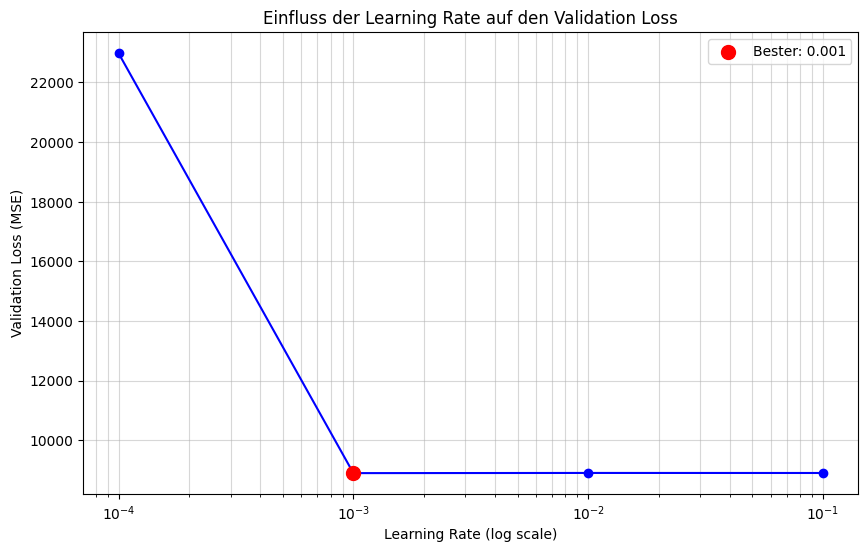

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---
Ergebnis LR 0.1: Finaler Val Loss (MSE) = 8893.7787

--- Teste Learning Rate: 0.01 ---
Ergebnis LR 0.01: Finaler Val Loss (MSE) = 8913.9845

--- Teste Learning Rate: 0.001 ---
Ergebnis LR 0.001: Finaler Val Loss (MSE) = 8899.9788

--- Teste Learning Rate: 0.0001 ---
Ergebnis LR 0.0001: Finaler Val Loss (MSE) = 22051.5531


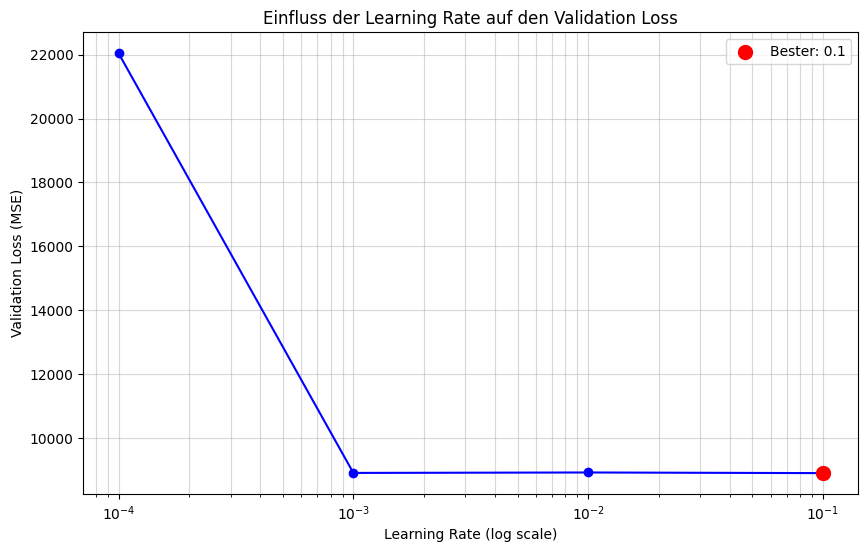

Starte Hyperparameter-Test für 4 Learning Rates...

--- Teste Learning Rate: 0.1 ---


KeyboardInterrupt: 

In [18]:
learning_rates = [0.1,0.01,0.001,0.0001]

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V1, best_loss_V2 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)

best_lr_V3, best_loss_V3 = test_learning_rates(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=512,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=50
)



In [34]:
def extract_features_resnet50(url_list):
    """
    Extrahiert Features mit ResNet50 (2048 Dimensionen).
    """
    # 1. Modell laden (pretrained)
    resnet = models.resnet50(pretrained=True)
    
    # 2. Den letzten Layer (Classifier) entfernen, um nur Features zu bekommen
    # ResNet50 endet mit (avgpool): Output ist (Batch, 2048, 1, 1)
    # Wir entfernen alles nach dem Pooling oder nutzen Sequential bis zum Pooling
    resnet = nn.Sequential(*list(resnet.children())[:-1]) # Entfernt den fc Layer
    
    resnet.eval() # Evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    resnet.to(device)
    
    # 3. Transformationen definieren (ResNet braucht spezifische Normalisierung)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    features_list = []
    
    print(f"Starte Extraktion mit ResNet50 für {len(url_list)} Bilder...")
    
    for url in tqdm(url_list, desc="ResNet50 Extraktion"):
        try:
            response = requests.get(url, timeout=5)
            img = Image.open(requests.get(url, stream=True).raw).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                feature_vector = resnet(img_tensor)
            
            # Shape ist (Batch, 2048, 1, 1) -> wir wollen (2048)
            feature_vector = feature_vector.flatten().cpu().numpy()
            features_list.append(feature_vector)
            
        except Exception as e:
            # Bei Fehler: Null-Vektor der Länge 2048
            features_list.append(np.zeros(2048))
            
    return np.array(features_list)

In [50]:
image_path_50 = 'X_images_resnet50.npy'

if os.path.exists(image_path_50):
    print("Lade ResNet50 Features...")
    X_images_50 = np.load(image_path_50, allow_pickle=True)
else:
    print("Berechne ResNet50 Features (das kann dauern!)...")
    # Annahme: df ist geladen und 'urls' sind definiert
    X_images = extract_features_resnet50(urls)
    np.save(image_path_50, X_images_50)
    print(f"Gespeichert! Shape: {X_images.shape}")

Lade ResNet50 Features...


In [51]:
X_train_img, X_val_img, X_test_img, y_train, y_val, y_test = split_data(X_images_50, y)
X_train_img_scaled, X_val_img_scaled, X_test_img_scaled = standardize_data(
    X_train_img,
    X_val_img,
    X_test_img)
train_loader_img, val_loader_img, test_loader_img = create_dataloaders(
    X_train=X_train_img_scaled,
    X_val=X_val_img_scaled,
    X_test=X_test_img_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    batch_size=batch_size
)

Split: Train=6460, Val=1384, Test=1385
Scaling abgeschlossen.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6


In [80]:
img_model_resnet50 = WideMLPModel(input_dim=2048, output_dim=1).to(device)

optimizer = torch.optim.AdamW(img_model_resnet50.parameters(), lr=0.1,weight_decay = 0.00005)
loss_fn = torch.nn.MSELoss()


Starte Hyperparameter-Test für 4 Learning Rates (100 Epochen)...

--- Teste Learning Rate: 0.01 ---
LR 0.01 beendet. Finaler Val Loss: 14136.3220

--- Teste Learning Rate: 0.001 ---
LR 0.001 beendet. Finaler Val Loss: 14098.8372

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 24609.3480

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 32049.1523


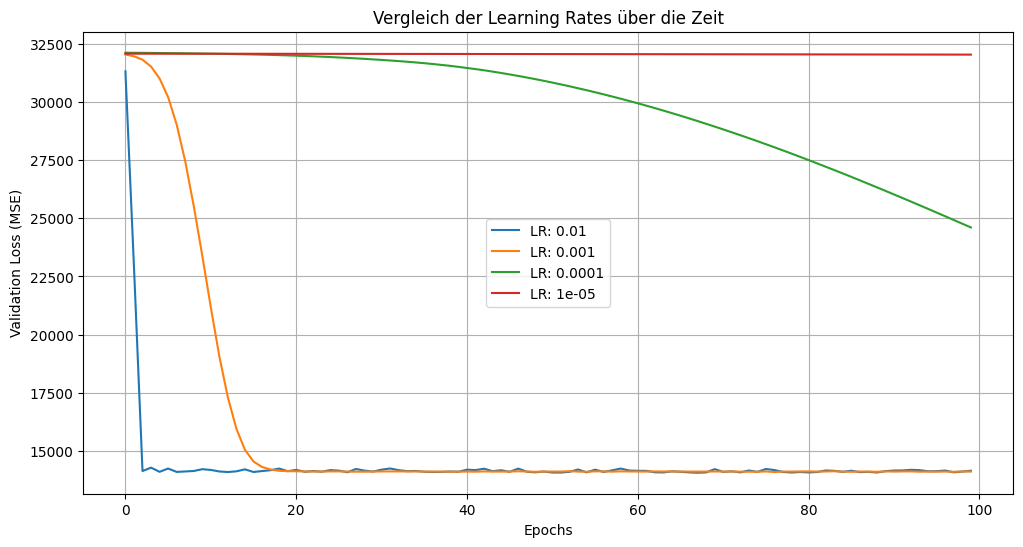


Bester finaler Val Loss bei LR: 0.001


In [68]:
learning_rates = [0.01,0.001,0.0001,0.00001]

all_val_losses = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=2048,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=100
)

Starte Hyperparameter-Test für 3 Learning Rates (100 Epochen)...

--- Teste Learning Rate: 0.0001 ---
LR 0.0001 beendet. Finaler Val Loss: 21284.5244

--- Teste Learning Rate: 1e-05 ---
LR 1e-05 beendet. Finaler Val Loss: 32072.8708

--- Teste Learning Rate: 1e-06 ---
LR 1e-06 beendet. Finaler Val Loss: 32157.4062


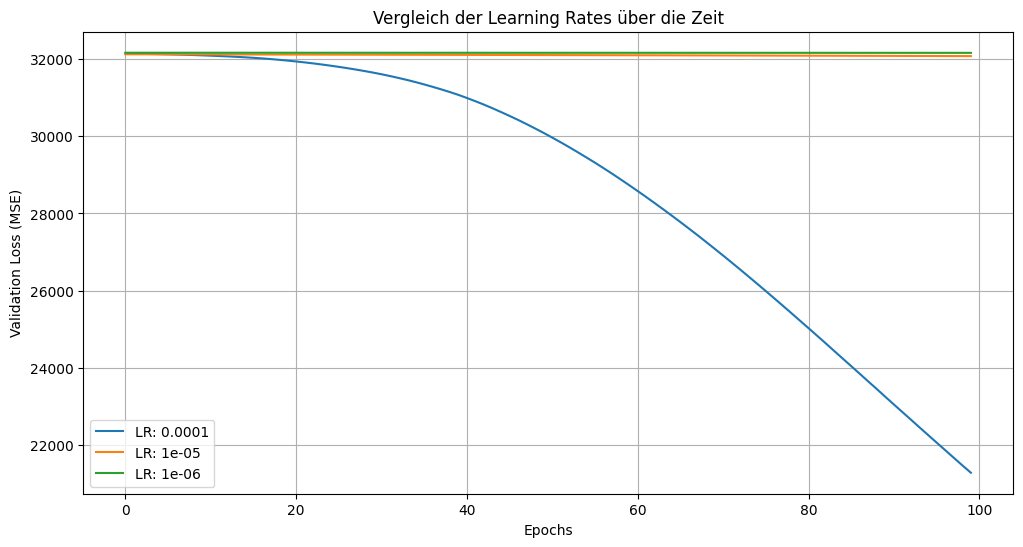


Bester finaler Val Loss bei LR: 0.0001


ValueError: too many values to unpack (expected 2)

In [70]:
learning_rates = [0.0001,0.00001,0.000001]

best_lr, best_loss = test_learning_rates_curves(
    learning_rates=learning_rates,
    model_class=MLPModel,
    input_dim=2048,
    output_dim=1,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    device=device,
    epochs=100
)

# plot_grad_flow torch in Pytorch forum

In [84]:
img_model_resnet50 = WideMLPModel(input_dim=2048, output_dim=1).to(device)

optimizer = torch.optim.Adam(img_model_resnet50.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()

In [85]:
train_losses, val_losses, train_rmses, val_rmses = run_training(
    model=img_model_resnet50,
    optimizer=optimizer,
    loss_function=loss_fn,
    device=device,
    num_epochs=100,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)

Starte Training für 100 Epochen...


<div><p>Epoch 1/100 | Train Loss (MSE): 26952.2383 | Train RMSE:       164.07€ | Val Loss (MSE):   32110.6318 | Val RMSE:         181.31€</p><p>Epoch 2/100 | Train Loss (MSE): 26892.0195 | Train RMSE:       163.83€ | Val Loss (MSE):   32070.1227 | Val RMSE:         181.20€</p><p>Epoch 3/100 | Train Loss (MSE): 26423.1993 | Train RMSE:       163.60€ | Val Loss (MSE):   31799.6986 | Val RMSE:         180.45€</p><p>Epoch 4/100 | Train Loss (MSE): 26721.5963 | Train RMSE:       163.36€ | Val Loss (MSE):   27822.5898 | Val RMSE:         169.04€</p><p>Epoch 5/100 | Train Loss (MSE): 26330.3162 | Train RMSE:       163.13€ | Val Loss (MSE):   24181.2267 | Val RMSE:         157.87€</p><p>Epoch 6/100 | Train Loss (MSE): 26495.2630 | Train RMSE:       162.89€ | Val Loss (MSE):   20575.6755 | Val RMSE:         145.96€</p><p>Epoch 7/100 | Train Loss (MSE): 26238.5373 | Train RMSE:       162.68€ | Val Loss (MSE):   21794.9220 | Val RMSE:         150.10€</p><p>Epoch 8/100 | Train Loss (MSE): 26440.4890 | Train RMSE:       162.46€ | Val Loss (MSE):   19051.2521 | Val RMSE:         140.62€</p><p>Epoch 9/100 | Train Loss (MSE): 26248.2252 | Train RMSE:       162.21€ | Val Loss (MSE):   21198.3034 | Val RMSE:         148.09€</p><p>Epoch 10/100 | Train Loss (MSE): 26411.3009 | Train RMSE:       161.99€ | Val Loss (MSE):   20780.0846 | Val RMSE:         146.67€</p><p>Epoch 11/100 | Train Loss (MSE): 26098.9306 | Train RMSE:       161.74€ | Val Loss (MSE):   19841.0386 | Val RMSE:         143.42€</p><p>Epoch 12/100 | Train Loss (MSE): 25868.9234 | Train RMSE:       161.50€ | Val Loss (MSE):   19359.6787 | Val RMSE:         141.72€</p><p>Epoch 13/100 | Train Loss (MSE): 26004.9874 | Train RMSE:       161.25€ | Val Loss (MSE):   19838.8643 | Val RMSE:         143.41€</p><p>Epoch 14/100 | Train Loss (MSE): 25829.1642 | Train RMSE:       161.01€ | Val Loss (MSE):   18898.5459 | Val RMSE:         140.08€</p><p>Epoch 15/100 | Train Loss (MSE): 25637.0273 | Train RMSE:       160.78€ | Val Loss (MSE):   17996.4969 | Val RMSE:         136.80€</p><p>Epoch 16/100 | Train Loss (MSE): 26240.2221 | Train RMSE:       160.52€ | Val Loss (MSE):   20497.7227 | Val RMSE:         145.70€</p><p>Epoch 17/100 | Train Loss (MSE): 25437.4005 | Train RMSE:       160.29€ | Val Loss (MSE):   17357.9862 | Val RMSE:         134.44€</p><p>Epoch 18/100 | Train Loss (MSE): 25651.2014 | Train RMSE:       160.02€ | Val Loss (MSE):   17574.8042 | Val RMSE:         135.24€</p><p>Epoch 19/100 | Train Loss (MSE): 25529.5181 | Train RMSE:       159.75€ | Val Loss (MSE):   17678.4316 | Val RMSE:         135.63€</p><p>Epoch 20/100 | Train Loss (MSE): 25331.1491 | Train RMSE:       159.48€ | Val Loss (MSE):   15893.8032 | Val RMSE:         128.84€</p><p>Epoch 21/100 | Train Loss (MSE): 25264.3937 | Train RMSE:       159.22€ | Val Loss (MSE):   17390.5098 | Val RMSE:         134.56€</p><p>Epoch 22/100 | Train Loss (MSE): 25112.0638 | Train RMSE:       158.97€ | Val Loss (MSE):   16196.3752 | Val RMSE:         130.02€</p><p>Epoch 23/100 | Train Loss (MSE): 25126.1620 | Train RMSE:       158.70€ | Val Loss (MSE):   14424.6009 | Val RMSE:         122.95€</p><p>Epoch 24/100 | Train Loss (MSE): 24989.9814 | Train RMSE:       158.40€ | Val Loss (MSE):   14080.8879 | Val RMSE:         121.50€</p><p>Epoch 25/100 | Train Loss (MSE): 24751.3595 | Train RMSE:       158.11€ | Val Loss (MSE):   15214.8787 | Val RMSE:         126.16€</p><p>Epoch 26/100 | Train Loss (MSE): 24758.4883 | Train RMSE:       157.82€ | Val Loss (MSE):   16903.5028 | Val RMSE:         132.73€</p><p>Epoch 27/100 | Train Loss (MSE): 24587.1572 | Train RMSE:       157.52€ | Val Loss (MSE):   15309.9784 | Val RMSE:         126.54€</p><p>Epoch 28/100 | Train Loss (MSE): 24927.1876 | Train RMSE:       157.18€ | Val Loss (MSE):   15848.7874 | Val RMSE:         128.66€</p><p>Epoch 29/100 | Train Loss (MSE): 24559.2352 | Train RMSE:       156.80€ | Val Loss (MSE):   17688.9530 | Val RMSE:         135.67€</p><p>Epoch 30/100 | Train Loss (M

Training beendet.


In [98]:
# Modell initialisieren
deep_model = DeepResidualMLP(input_dim=2048, output_dim=1).to(device)

# Optimizer
optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.00001) # 0.001 ist bei ResNets oft besser

# Training
history = run_training(
    model=deep_model,
    optimizer=optimizer,
    loss_function=loss_fn,
    device=device,
    num_epochs=20,
    train_dataloader=train_loader_img,
    val_dataloader=val_loader_img
)

Starte Training für 20 Epochen...


<div><div><progress max="20" value="9"></progress> 45.00% [9/20 00:33&lt;00:41]</div><div><p>Epoch 1/20 | Train Loss (MSE): 27490.8863 | Train RMSE:       163.89€ | Val Loss (MSE):   32039.7676 | Val RMSE:         181.12€</p><p>Epoch 2/20 | Train Loss (MSE): 27022.3694 | Train RMSE:       163.80€ | Val Loss (MSE):   31993.1504 | Val RMSE:         180.99€</p><p>Epoch 3/20 | Train Loss (MSE): 26690.5347 | Train RMSE:       163.69€ | Val Loss (MSE):   25773.0280 | Val RMSE:         162.85€</p><p>Epoch 4/20 | Train Loss (MSE): 26583.5622 | Train RMSE:       163.60€ | Val Loss (MSE):   27759850.3333 | Val RMSE:         5268.51€</p><p>Epoch 5/20 | Train Loss (MSE): 26651.1998 | Train RMSE:       163.51€ | Val Loss (MSE):   272857877.3333 | Val RMSE:         16518.12€</p><p>Epoch 6/20 | Train Loss (MSE): 26561.4331 | Train RMSE:       163.41€ | Val Loss (MSE):   539108554.6667 | Val RMSE:         23218.41€</p><p>Epoch 7/20 | Train Loss (MSE): 26386.9021 | Train RMSE:       163.33€ | Val Loss (MSE):   903895882.6667 | Val RMSE:         30064.56€</p><p>Epoch 8/20 | Train Loss (MSE): 26455.5177 | Train RMSE:       163.24€ | Val Loss (MSE):   814909845.3333 | Val RMSE:         28546.32€</p><p>Epoch 9/20 | Train Loss (MSE): 26425.9277 | Train RMSE:       163.13€ | Val Loss (MSE):   607591146.6667 | Val RMSE:         24649.06€</p></div><div><progress max="26" value="23"></progress> 88.46% [23/26 00:03&lt;00:00]</div></div>

KeyboardInterrupt: 

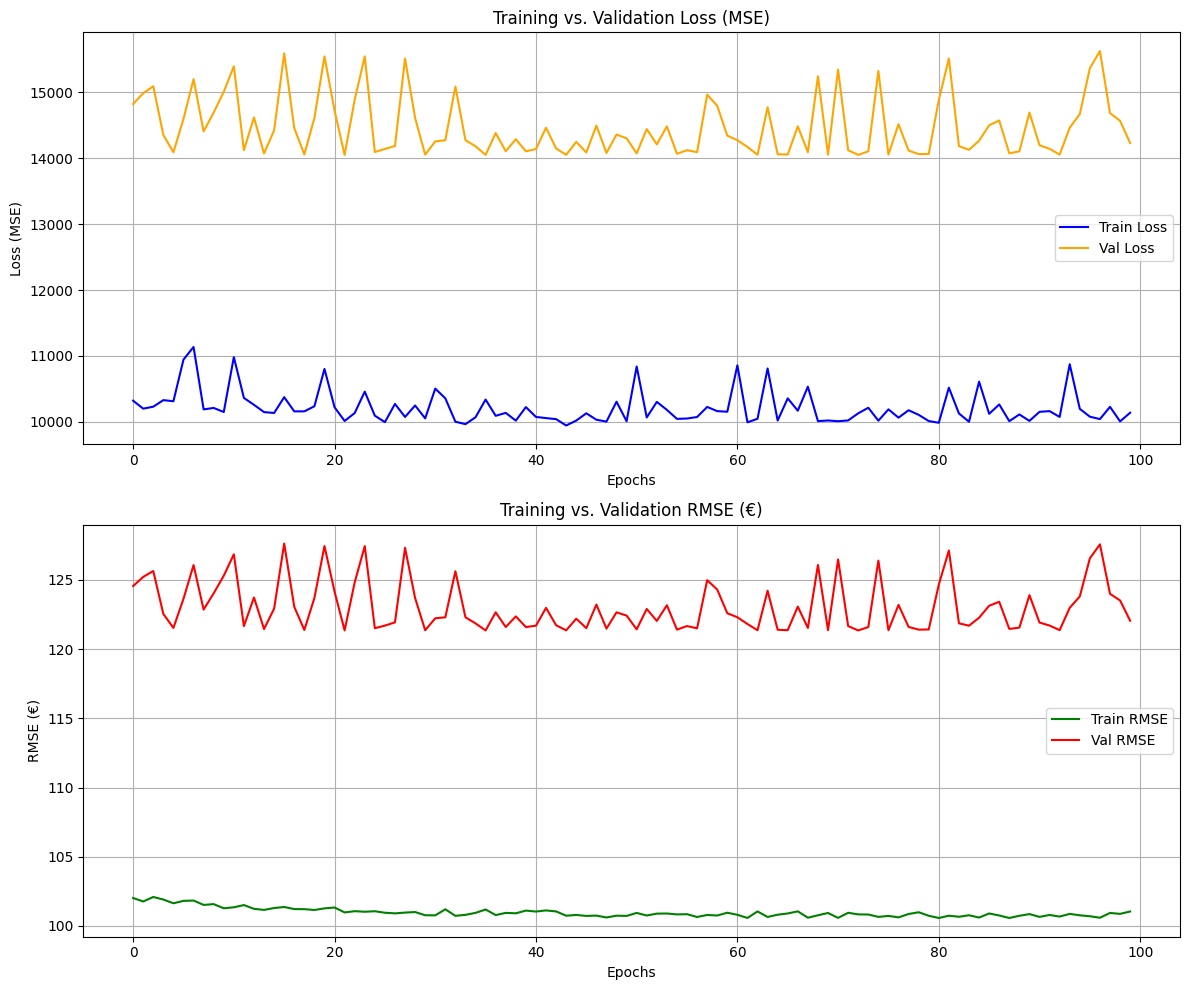

Beste Epoche: 36
Bester Validation RMSE: 121.35€

Modell scheint gut generalisiert zu haben.


In [77]:
import matplotlib.pyplot as plt

# --- PLOTTING ---

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# 1. PLOT: LOSS (MSE)
axs[0].plot(train_losses, label='Train Loss', color='blue')
axs[0].plot(val_losses, label='Val Loss', color='orange')

axs[0].set_title('Training vs. Validation Loss (MSE)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (MSE)')
axs[0].legend()
axs[0].grid(True)

# 2. PLOT: RMSE
axs[1].plot(train_rmses, label='Train RMSE', color='green')
axs[1].plot(val_rmses, label='Val RMSE', color='red')

axs[1].set_title('Training vs. Validation RMSE (€)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('RMSE (€)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(val_rmses)
best_val_rmse = val_rmses[best_epoch]

print(f"Beste Epoche: {best_epoch + 1}")
print(f"Bester Validation RMSE: {best_val_rmse:.2f}€")


In [57]:

sys.path.append('/kaggle/working/Machine-Learning-Final-project')

from src.models.architectures import WideMLPModel # Dein Modell
from src.data.dataset import create_dataloaders # Deine DataLoader
from src.models.trainer import run_training # Dein Training Loop

# Wir brauchen globale Variablen für die Daten, damit Optuna sie nicht jedes Mal neu lädt
# (Angenommen, X_train_s, y_train etc. sind schon im Speicher definiert)

def objective(trial):
    """
    Diese Funktion wird von Optuna optimiert.
    """
    
    # 1. Hyperparameter vorschlagen (Search Space)
    
    # Learning Rate: Log-Uniform zwischen 0.0001 und 0.1
    lr = trial.suggest_float("lr", 0.0000001, 0.1, log=True)
    
    # Dropout: Uniform zwischen 0.1 und 0.5
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    
    # Batch Size:
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    
    # Anzahl Hidden Layers: Int zwischen 2 und 4
    n_layers = trial.suggest_int("n_layers", 2, 5)
    
    # Neuronen pro Layer: Int zwischen 256 und 1024
    n_units = trial.suggest_int("n_units", 128, 1024)
    
    # 2. Modell bauen (Hier müssen wir etwas flexibler sein)
    # Da WideMLPModel fest codiert ist, bauen wir hier ein einfaches MLP dynamisch
    layers = []
    input_dim = 2048 # ResNet50 Features
    
    # Erster Layer
    layers.append(nn.Linear(input_dim, n_units))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(dropout))
    
    # Versteckte Layer
    for _ in range(n_layers - 1):
        layers.append(nn.Linear(n_units, n_units))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        
    # Output Layer
    layers.append(nn.Linear(n_units, 1))
    
    model = deep_model.to(device)
    
    # 3. Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    
    # 4. DataLoader erstellen (mit der aktuellen batch_size)
    # Achtung: Das erstellt neue DataLoader, was etwas dauert
    train_loader, val_loader, _ = create_dataloaders(
        X_train=X_train_img_scaled, # Deine skalierten Trainingsdaten
        X_val=X_val_img_scaled,
        X_test=X_test_img_scaled,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        batch_size=batch_size
    )
    
    # 5. Training (Nur kurz, z.B. 10 Epochen)
    # Wir nutzen run_training, aber nur für 10 Epochen um Zeit zu sparen
    _, _, _, val_rmses = run_training(
        model=model,
        optimizer=optimizer,
        loss_function=loss_fn,
        device=device,
        num_epochs=20, 
        train_dataloader=train_loader,
        val_dataloader=val_loader
    )
    
    # 6. Rückgabe: Optuna minimiert diesen Wert
    # Wir nehmen den besten RMSE der 10 Epochen
    best_val_rmse = np.min(val_rmses)
    
    return best_val_rmse

In [ ]:
warnings.filterwarnings("ignore")

# Studie erstellen
study = optuna.create_study(direction="minimize") # Wir wollen den RMSE minimieren

print("Starte Optuna Optimierung... (Das kann dauern!)")

# 20 Versuche (Trials)
study.optimize(objective, n_trials=20)

print("\nOptimierung beendet!")

[I 2026-07-01 12:42:55,052] A new study created in memory with name: no-name-1e8d2be5-1a29-4a3f-b11a-37cb78de6dff


Starte Optuna Optimierung... (Das kann dauern!)
DataLoader bereit (Batch Size 32):
  Train Batches: 202
  Val Batches: 44
  Test Batches: 44
Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 12894.1752 | Train RMSE:       113.55€ | Val Loss (MSE):   11984.1961 | Val RMSE:         109.73€</p><p>Epoch 2/20 | Train Loss (MSE): 12196.1719 | Train RMSE:       110.38€ | Val Loss (MSE):   10656.9464 | Val RMSE:         103.51€</p><p>Epoch 3/20 | Train Loss (MSE): 12093.8377 | Train RMSE:       109.99€ | Val Loss (MSE):   10541.1966 | Val RMSE:         102.96€</p><p>Epoch 4/20 | Train Loss (MSE): 12109.0749 | Train RMSE:       110.06€ | Val Loss (MSE):   10572.8268 | Val RMSE:         103.11€</p><p>Epoch 5/20 | Train Loss (MSE): 11976.2437 | Train RMSE:       109.45€ | Val Loss (MSE):   10843.5784 | Val RMSE:         104.41€</p><p>Epoch 6/20 | Train Loss (MSE): 11888.4112 | Train RMSE:       109.05€ | Val Loss (MSE):   10536.4543 | Val RMSE:         102.93€</p><p>Epoch 7/20 | Train Loss (MSE): 11828.9446 | Train RMSE:       108.78€ | Val Loss (MSE):   10551.0468 | Val RMSE:         103.00€</p><p>Epoch 8/20 | Train Loss (MSE): 11904.0914 | Train RMSE:       109.12€ | Val Loss (MSE):   10590.7170 | Val RMSE:         103.20€</p><p>Epoch 9/20 | Train Loss (MSE): 11870.5544 | Train RMSE:       108.97€ | Val Loss (MSE):   10600.0271 | Val RMSE:         103.25€</p><p>Epoch 10/20 | Train Loss (MSE): 11879.3785 | Train RMSE:       109.01€ | Val Loss (MSE):   10533.4150 | Val RMSE:         102.92€</p><p>Epoch 11/20 | Train Loss (MSE): 11826.7376 | Train RMSE:       108.77€ | Val Loss (MSE):   10533.8355 | Val RMSE:         102.92€</p><p>Epoch 12/20 | Train Loss (MSE): 11862.5656 | Train RMSE:       108.94€ | Val Loss (MSE):   10585.1023 | Val RMSE:         103.17€</p><p>Epoch 13/20 | Train Loss (MSE): 11896.8910 | Train RMSE:       109.08€ | Val Loss (MSE):   10532.2806 | Val RMSE:         102.91€</p><p>Epoch 14/20 | Train Loss (MSE): 11865.3626 | Train RMSE:       108.91€ | Val Loss (MSE):   10638.7985 | Val RMSE:         103.43€</p><p>Epoch 15/20 | Train Loss (MSE): 11790.1828 | Train RMSE:       108.60€ | Val Loss (MSE):   10536.2815 | Val RMSE:         102.93€</p><p>Epoch 16/20 | Train Loss (MSE): 11817.0474 | Train RMSE:       108.70€ | Val Loss (MSE):   10746.6449 | Val RMSE:         103.96€</p><p>Epoch 17/20 | Train Loss (MSE): 11766.5022 | Train RMSE:       108.48€ | Val Loss (MSE):   10560.3202 | Val RMSE:         103.05€</p><p>Epoch 18/20 | Train Loss (MSE): 11794.2118 | Train RMSE:       108.62€ | Val Loss (MSE):   10560.3261 | Val RMSE:         103.05€</p><p>Epoch 19/20 | Train Loss (MSE): 11814.5746 | Train RMSE:       108.72€ | Val Loss (MSE):   10663.5326 | Val RMSE:         103.55€</p><p>Epoch 20/20 | Train Loss (MSE): 11821.0424 | Train RMSE:       108.75€ | Val Loss (MSE):   10627.8220 | Val RMSE:         103.38€</p></div>

[I 2026-07-01 12:44:12,937] Trial 0 finished with value: 102.91453892026394 and parameters: {'lr': 0.010727211776915975, 'dropout': 0.3066293425950744, 'batch_size': 32, 'n_layers': 4, 'n_units': 460}. Best is trial 0 with value: 102.91453892026394.


Training beendet.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6
Starte Training für 20 Epochen...


...

Training beendet.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6
Starte Training für 20 Epochen...


<div><p>Epoch 1/20 | Train Loss (MSE): 29184.5834 | Train RMSE:       169.43€ | Val Loss (MSE):   27251.4629 | Val RMSE:         160.90€</p><p>Epoch 2/20 | Train Loss (MSE): 23578.2742 | Train RMSE:       154.37€ | Val Loss (MSE):   17207.5369 | Val RMSE:         126.28€</p><p>Epoch 3/20 | Train Loss (MSE): 13669.9256 | Train RMSE:       114.81€ | Val Loss (MSE):   12082.4456 | Val RMSE:         104.92€</p><p>Epoch 4/20 | Train Loss (MSE): 11635.1360 | Train RMSE:       108.28€ | Val Loss (MSE):   11709.6346 | Val RMSE:         102.92€</p><p>Epoch 5/20 | Train Loss (MSE): 12090.7595 | Train RMSE:       107.89€ | Val Loss (MSE):   11709.2157 | Val RMSE:         102.95€</p><p>Epoch 6/20 | Train Loss (MSE): 11708.5266 | Train RMSE:       107.72€ | Val Loss (MSE):   11707.4692 | Val RMSE:         102.94€</p><p>Epoch 7/20 | Train Loss (MSE): 11449.3516 | Train RMSE:       107.86€ | Val Loss (MSE):   11710.0511 | Val RMSE:         102.96€</p><p>Epoch 8/20 | Train Loss (MSE): 11558.8831 | Train RMSE:       107.90€ | Val Loss (MSE):   11706.5863 | Val RMSE:         102.91€</p><p>Epoch 9/20 | Train Loss (MSE): 11447.9984 | Train RMSE:       107.72€ | Val Loss (MSE):   11706.4230 | Val RMSE:         102.92€</p><p>Epoch 10/20 | Train Loss (MSE): 11943.2218 | Train RMSE:       107.75€ | Val Loss (MSE):   11724.4571 | Val RMSE:         103.05€</p><p>Epoch 11/20 | Train Loss (MSE): 11703.9362 | Train RMSE:       107.92€ | Val Loss (MSE):   11726.8743 | Val RMSE:         102.98€</p><p>Epoch 12/20 | Train Loss (MSE): 11779.0339 | Train RMSE:       107.86€ | Val Loss (MSE):   11707.7002 | Val RMSE:         102.94€</p><p>Epoch 13/20 | Train Loss (MSE): 11967.8206 | Train RMSE:       107.78€ | Val Loss (MSE):   11706.1767 | Val RMSE:         102.92€</p><p>Epoch 14/20 | Train Loss (MSE): 11411.0221 | Train RMSE:       107.78€ | Val Loss (MSE):   11725.9179 | Val RMSE:         102.97€</p><p>Epoch 15/20 | Train Loss (MSE): 11476.8614 | Train RMSE:       107.84€ | Val Loss (MSE):   11722.9935 | Val RMSE:         103.04€</p><p>Epoch 16/20 | Train Loss (MSE): 11430.4568 | Train RMSE:       107.88€ | Val Loss (MSE):   11706.1042 | Val RMSE:         102.92€</p><p>Epoch 17/20 | Train Loss (MSE): 11535.5649 | Train RMSE:       107.85€ | Val Loss (MSE):   11710.1890 | Val RMSE:         102.92€</p><p>Epoch 18/20 | Train Loss (MSE): 11656.8068 | Train RMSE:       107.96€ | Val Loss (MSE):   11706.1246 | Val RMSE:         102.92€</p><p>Epoch 19/20 | Train Loss (MSE): 12343.3914 | Train RMSE:       107.89€ | Val Loss (MSE):   11732.3052 | Val RMSE:         103.10€</p><p>Epoch 20/20 | Train Loss (MSE): 11435.5845 | Train RMSE:       107.89€ | Val Loss (MSE):   11726.1607 | Val RMSE:         102.97€</p></div>

[I 2026-07-01 12:56:43,608] Trial 18 finished with value: 102.91494678459635 and parameters: {'lr': 0.0012972204339106199, 'dropout': 0.26577699417128126, 'batch_size': 256, 'n_layers': 2, 'n_units': 636}. Best is trial 13 with value: 102.91451105642322.


Training beendet.
DataLoader bereit (Batch Size 256):
  Train Batches: 26
  Val Batches: 6
  Test Batches: 6
Starte Training für 20 Epochen...


<div><div><progress max="20" value="8"></progress> 40.00% [8/20 00:11&lt;00:16]</div><div><p>Epoch 1/20 | Train Loss (MSE): 28719.3763 | Train RMSE:       170.47€ | Val Loss (MSE):   28709.2803 | Val RMSE:         165.34€</p><p>Epoch 2/20 | Train Loss (MSE): 28672.8018 | Train RMSE:       170.39€ | Val Loss (MSE):   28677.9740 | Val RMSE:         165.24€</p><p>Epoch 3/20 | Train Loss (MSE): 28801.2938 | Train RMSE:       170.28€ | Val Loss (MSE):   28626.3359 | Val RMSE:         165.09€</p><p>Epoch 4/20 | Train Loss (MSE): 29036.0590 | Train RMSE:       170.06€ | Val Loss (MSE):   28526.3402 | Val RMSE:         164.79€</p><p>Epoch 5/20 | Train Loss (MSE): 28574.0326 | Train RMSE:       169.65€ | Val Loss (MSE):   28333.4508 | Val RMSE:         164.20€</p><p>Epoch 6/20 | Train Loss (MSE): 28897.8341 | Train RMSE:       168.88€ | Val Loss (MSE):   27992.1367 | Val RMSE:         163.17€</p><p>Epoch 7/20 | Train Loss (MSE): 28177.8696 | Train RMSE:       167.56€ | Val Loss (MSE):   27434.4535 | Val RMSE:         161.47€</p><p>Epoch 8/20 | Train Loss (MSE): 27188.4229 | Train RMSE:       165.46€ | Val Loss (MSE):   26583.1888 | Val RMSE:         158.83€</p></div><div><progress max="26" value="17"></progress> 65.38% [17/26 00:00&lt;00:00]</div></div>

In [59]:
print("Beste Hyperparameter:")
print(study.best_params)

print(f"Bester RMSE: {study.best_value:.2f}€")

# Plot der Optimierungshistorie
optuna.visualization.plot_optimization_history(study).show()

Beste Hyperparameter:
{'lr': 0.09022488542760974, 'dropout': 0.22682464594432145, 'batch_size': 256, 'n_layers': 3, 'n_units': 565}
Bester RMSE: 102.91€
